# 下載安裝 Ultralytics YOLO26 並執行基礎物件偵測

2026/04/20, Jack OmniXRI 整理製作

使用 Yolo26 原始 PyTorch + COCO 預訓練物件偵測模型進行推論

原始資料來源：https://colab.research.google.com/github/openvinotoolkit/openvino_notebooks/blob/latest/notebooks/yolov26-optimization/yolov26-object-detection.ipynb#scrollTo=30dd6b4b


# 1. 取得並安裝必要函式庫


In [1]:
import platform

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"


#%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.22" tqdm opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00


# 2.選擇 Yolo26 模型

可選擇不同大小的模型，包括 "yolo26n", "yolo26s", "yolo26m", "yolo26l", "yolo26x"， 預設為 "yolo26n"

In [2]:
import ipywidgets as widgets

model_id = ["yolo26n", "yolo26s", "yolo26m", "yolo26l", "yolo26x"]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yolo26n', 'yolo26s', 'yolo26m', 'yolo26l', 'yolo26x'), value='yolo26n'…

# 3.指定物件偵測推論模型及裝置並進行推論

在 Colab 中使用 OpenVINO 裝置只能選 CPU(XEON)

指定並下載影像並執行推論

顯示推論結果

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/golden-retriever-tongue-out.jpg: 416x640 1 dog, 304.2ms
Speed: 13.3ms preprocess, 304.2ms inference, 5.7ms postprocess per image at shape (1, 3, 416, 640)


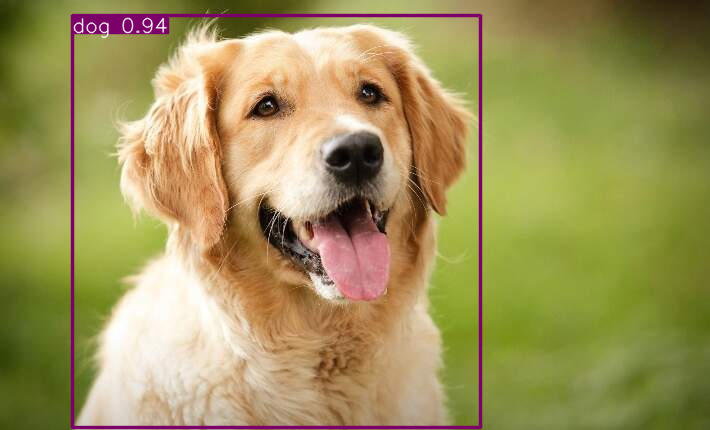

In [3]:
from PIL import Image
from ultralytics import YOLO

DET_MODEL_NAME = model_name.value

det_model = YOLO(f"{DET_MODEL_NAME}.pt")
det_model.to("cpu")
label_map = det_model.model.names

#res = det_model(IMAGE_PATH)
res = det_model("https://www.nylabone.com/-/media/project/oneweb/nylabone/images/dog101/10-intelligent-dog-breeds/golden-retriever-tongue-out.jpg")
Image.fromarray(res[0].plot()[:, :, ::-1])